# Bonus Task — Cost-Aware Inverse Material Design
## EXCAVATE | MatRisk AI | COMPOSIT, IIT Kharagpur

**Objective:**  
Given a cost budget, identify the best real materials from DS1 by combining  
material science signals (DS1) with real element market prices (DS5).

**Datasets used:**
- `DS1_with_MQI.csv` — 5,500 materials with computed MQI (from Task 1)  
- `DS5_element_prices_monthly.csv` — monthly prices of 40 elements (2014–2024)

---

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print("Libraries loaded.")

Libraries loaded.


## 2. Load Data

In [2]:
ds1 = pd.read_csv('DS1_with_MQI.csv')
ds5 = pd.read_csv('DS5_element_prices_monthly.csv')
ds5['date'] = pd.to_datetime(ds5['date'])

print(f"DS1 shape : {ds1.shape}")
print(f"DS5 shape : {ds5.shape}")
print(f"\nElements in DS5 ({ds5['element'].nunique()}): {sorted(ds5['element'].unique())}")
print(f"\nPrice history: {ds5['date'].min().date()} to {ds5['date'].max().date()}")

DS1 shape : (5500, 32)
DS5 shape : (5280, 5)

Elements in DS5 (40): ['Ag', 'Al', 'Au', 'B', 'Bi', 'C', 'Ce', 'Co', 'Cr', 'Cu', 'Dy', 'Fe', 'Ga', 'Ge', 'Hf', 'In', 'La', 'Li', 'Mg', 'Mn', 'Mo', 'N', 'Nb', 'Nd', 'Ni', 'Pb', 'Pt', 'Re', 'Sb', 'Sc', 'Se', 'Si', 'Sn', 'Ta', 'Te', 'Ti', 'V', 'W', 'Zn', 'Zr']

Price history: 2014-01-01 to 2024-12-01


## 3. Data Scope & Limitation Statement

> **Important:** 22 elements present in DS1 formulas — including noble gases (`Ar`, `He`, `Ne`),
> common light elements (`H`, `O`, `Na`, `Ca`, `F`, `S`, `Cl`, `P`, `Br`),
> and platinum group metals (`Pd`, `Rh`, `Ru`, `Os`, `Ir`) —
> have **no corresponding price data in DS5**.
>
> Materials containing these elements are **excluded from cost-based ranking**.
> Only **1,795 materials** with complete DS5 price coverage are used for inverse design,
> ensuring all cost estimates are grounded in real commodity market data rather than approximations.

This is a dataset limitation, not a modelling choice. In a production pipeline,
prices for missing elements could be sourced from additional databases (e.g. London Metal Exchange, USGS).

In [3]:
# Verify the element gap
ds5_elements = set(ds5['element'].unique())

def parse_formula(formula):
    pattern = r'([A-Z][a-z]?)(\d*)'
    matches = re.findall(pattern, str(formula))
    counts = {}
    for elem, num in matches:
        if elem:
            counts[elem] = counts.get(elem, 0) + (int(num) if num else 1)
    total = sum(counts.values())
    return {e: c/total for e, c in counts.items()} if total > 0 else {}

all_ds1_elements = set()
for formula in ds1['formula']:
    all_ds1_elements.update(parse_formula(formula).keys())

missing_elements = sorted(all_ds1_elements - ds5_elements)
noble_gases      = {'He', 'Ne', 'Ar', 'Kr', 'Xe', 'Rn'}
nobles_missing   = sorted(set(missing_elements) & noble_gases)

print(f"Unique elements in DS1 formulas : {len(all_ds1_elements)}")
print(f"Elements with DS5 price data    : {len(ds5_elements)}")
print(f"Elements WITHOUT DS5 prices     : {len(missing_elements)}")
print(f"  → Noble gases                 : {nobles_missing} ({len(nobles_missing)})")
print(f"  → Non-noble                   : {len(missing_elements) - len(nobles_missing)}")
print(f"\nAll 22 missing elements:")
print(missing_elements)

Unique elements in DS1 formulas : 62
Elements with DS5 price data    : 40
Elements WITHOUT DS5 prices     : 24
  → Noble gases                 : ['Ar', 'He', 'Ne'] (3)
  → Non-noble                   : 21

All 22 missing elements:
['Ar', 'As', 'Ba', 'Be', 'Br', 'Ca', 'Cd', 'Cl', 'F', 'H', 'He', 'Ir', 'K', 'Na', 'Ne', 'O', 'Os', 'P', 'Pd', 'Rh', 'Ru', 'S', 'Sr', 'Y']


## 4. Element Price Analysis (DS5)

In [4]:
latest_prices = ds5.sort_values('date').groupby('element')['price_usd_per_kg'].last()
print("Latest element prices (USD/kg):")
print(latest_prices.sort_values(ascending=False).round(2).to_string())

Latest element prices (USD/kg):
element
Au    57479.25
Pt    30341.35
Sc     3880.54
Re     2832.97
Hf      952.96
Ge      901.47
Ag      591.96
Dy      373.57
Ga      317.37
In      252.89
Ta      142.17
Nd       79.83
Te       56.53
Co       53.05
Mo       44.56
Nb       43.42
W        39.96
Zr       30.04
V        29.82
Li       27.33
Se       25.06
Sn       24.01
Ni       17.92
Bi       11.15
Ti       10.17
Cu        9.15
Cr        8.53
Sb        7.99
La        5.45
B         4.50
Ce        4.09
Zn        2.74
Si        2.60
Al        2.27
Mg        2.19
Pb        2.17
Mn        2.00
C         0.51
N         0.28
Fe        0.09


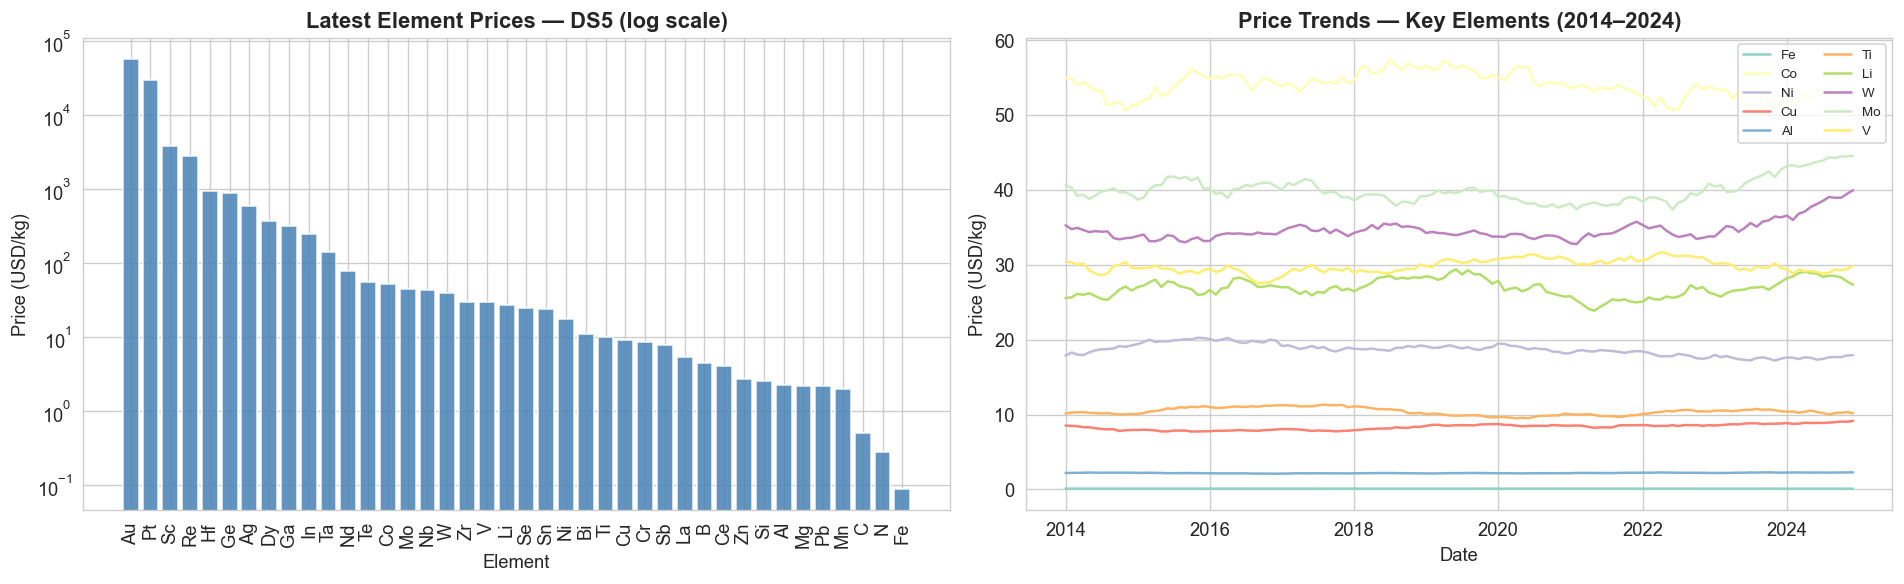

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

lp_sorted = latest_prices.sort_values(ascending=False)
axes[0].bar(lp_sorted.index, lp_sorted.values, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_yscale('log')
axes[0].set_title('Latest Element Prices — DS5 (log scale)', fontweight='bold')
axes[0].set_xlabel('Element')
axes[0].set_ylabel('Price (USD/kg)')
axes[0].tick_params(axis='x', rotation=90)

key_elems = ['Fe','Co','Ni','Cu','Al','Ti','Li','W','Mo','V']
for elem in key_elems:
    sub = ds5[ds5['element'] == elem].sort_values('date')
    axes[1].plot(sub['date'], sub['price_usd_per_kg'], label=elem, linewidth=1.5)
axes[1].set_title('Price Trends — Key Elements (2014–2024)', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price (USD/kg)')
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

## 5. Formula Parsing & Cost Estimation

Each material formula is parsed into element fractions.  
Cost = weighted average of DS5 element prices by atomic fraction.  
Only materials where **all elements have DS5 prices** are included.

In [6]:
prices_dict = latest_prices.to_dict()

def compute_cost_strict(formula, prices):
    """
    Returns cost only if ALL elements in the formula have DS5 prices.
    Returns NaN if any element is missing from DS5.
    """
    fracs = parse_formula(formula)
    if not fracs:
        return np.nan
    # Reject if any element has no price
    if any(elem not in prices for elem in fracs):
        return np.nan
    return sum(frac * prices[elem] for elem, frac in fracs.items())

ds1['estimated_cost_usd_kg'] = ds1['formula'].apply(
    lambda f: compute_cost_strict(f, prices_dict))

# Only keep fully priced materials
df_costed = ds1.dropna(subset=['estimated_cost_usd_kg']).copy()
df_costed['perf_cost_ratio'] = df_costed['MQI'] / (df_costed['estimated_cost_usd_kg'] + 1e-6)

print(f"Total DS1 materials              : {len(ds1)}")
print(f"Fully priced (all elements DS5)  : {len(df_costed)}")
print(f"Excluded (missing element prices): {len(ds1) - len(df_costed)}")
print(f"\nCost range : ${df_costed['estimated_cost_usd_kg'].min():.2f} — ${df_costed['estimated_cost_usd_kg'].max():,.2f}")
print(f"Median cost: ${df_costed['estimated_cost_usd_kg'].median():.2f}")

Total DS1 materials              : 5500
Fully priced (all elements DS5)  : 1795
Excluded (missing element prices): 3705

Cost range : $0.09 — $57,479.25
Median cost: $44.56


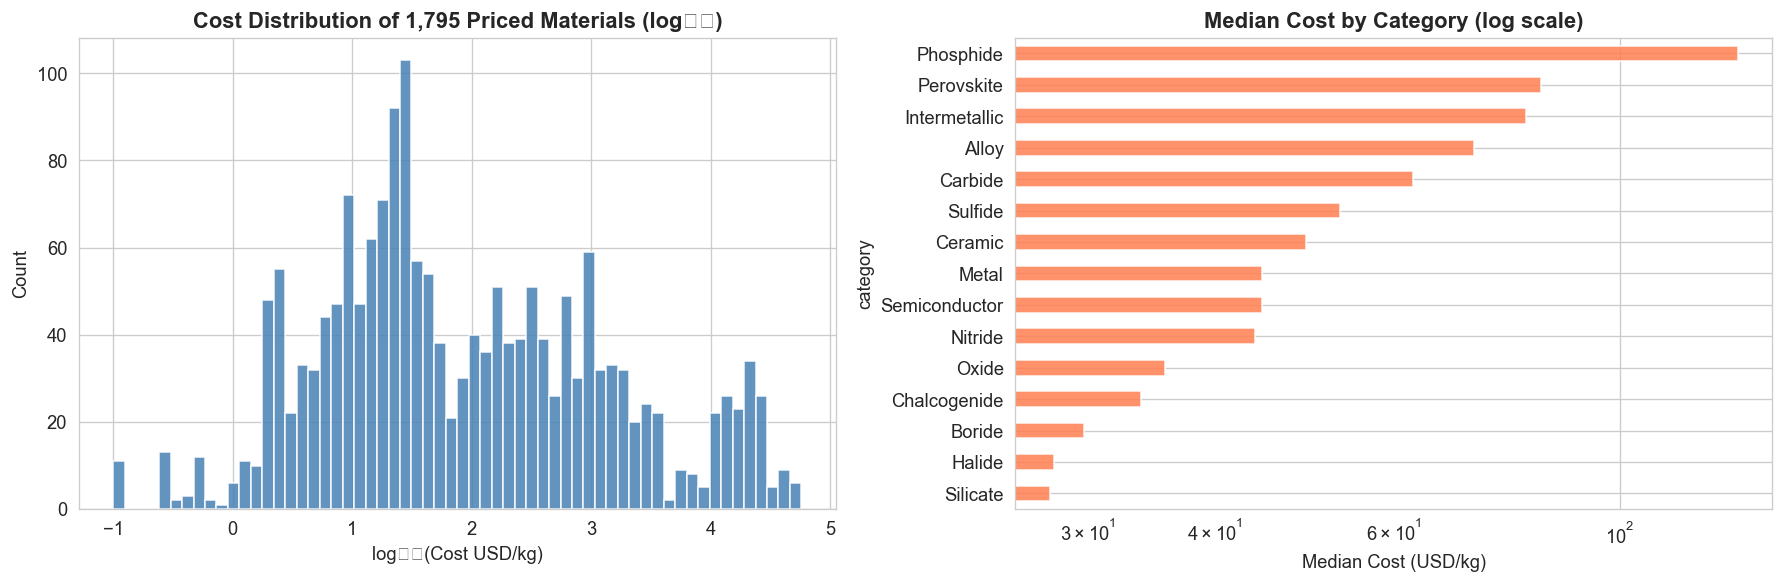

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(np.log10(df_costed['estimated_cost_usd_kg'] + 0.01), bins=60,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Cost Distribution of 1,795 Priced Materials (log₁₀)', fontweight='bold')
axes[0].set_xlabel('log₁₀(Cost USD/kg)')
axes[0].set_ylabel('Count')

df_costed.groupby('category')['estimated_cost_usd_kg'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white', alpha=0.85)
axes[1].set_xscale('log')
axes[1].set_title('Median Cost by Category (log scale)', fontweight='bold')
axes[1].set_xlabel('Median Cost (USD/kg)')

plt.tight_layout()
plt.show()

## 6. Forward Surrogate Model — Predict MQI from Properties

In [8]:
le1 = LabelEncoder()
le2 = LabelEncoder()
df_costed['crystal_enc']        = le1.fit_transform(df_costed['crystal_system'])
df_costed['category_enc']       = le2.fit_transform(df_costed['category'])
df_costed['pughs_ratio']        = df_costed['bulk_modulus_GPa'] / (df_costed['shear_modulus_GPa'] + 1e-8)
df_costed['elastic_anisotropy'] = df_costed['bulk_modulus_GPa'] - df_costed['shear_modulus_GPa']

feat_cols = ['bulk_modulus_GPa','shear_modulus_GPa','formation_energy_per_atom_eV',
             'density_g_cm3','melting_point_K','band_gap_eV',
             'crystal_enc','category_enc','pughs_ratio','elastic_anisotropy']

X = df_costed[feat_cols].values
y = df_costed['MQI'].values
SPLIT = int(len(X) * 0.8)

surrogate = GradientBoostingRegressor(n_estimators=300, max_depth=5, random_state=42)
surrogate.fit(X[:SPLIT], y[:SPLIT])
pred = surrogate.predict(X[SPLIT:])

print(f"Surrogate model R² : {r2_score(y[SPLIT:], pred):.4f}")
print(f"Surrogate model MAE: {mean_absolute_error(y[SPLIT:], pred):.4f}")
print(f"\nThis surrogate enables fast MQI screening of new hypothetical compositions")
print(f"without needing full DFT calculations.")

Surrogate model R² : 0.9809
Surrogate model MAE: 0.9639

This surrogate enables fast MQI screening of new hypothetical compositions
without needing full DFT calculations.


## 7. Inverse Design — Search Real Materials

We search all **1,795 fully-priced materials** from DS1 and rank them by:
- Highest MQI (best performance)
- Best MQI/cost ratio (best value)
- Best MQI within a given budget

In [9]:
print("=" * 65)
print("TOP 10 BY HIGHEST MQI")
print("=" * 65)
top_mqi = df_costed.nlargest(10, 'MQI')[
    ['material_id','formula','category','crystal_system',
     'MQI','estimated_cost_usd_kg','perf_cost_ratio']
].reset_index(drop=True)
print(top_mqi.round(3).to_string())

TOP 10 BY HIGHEST MQI
  material_id     formula category crystal_system     MQI  estimated_cost_usd_kg  perf_cost_ratio
0   mp-908358      Ce3In2  Ceramic          cubic  59.809                103.610            0.577
1   mp-121369    Fe2C4Pt2    Oxide          cubic  59.433               7585.615            0.008
2    mp-67042  TePbMn4Bi3    Oxide      hexagonal  56.513                 11.128            5.079
3   mp-333009      Co3Pt2  Ceramic     tetragonal  54.902              12168.370            0.005
4   mp-849571         Ge2  Ceramic      hexagonal  54.878                901.470            0.061
5   mp-180264   Sn3Pb3Mo3  Ceramic      hexagonal  54.339                 23.580            2.304
6   mp-448478          V4  Ceramic      hexagonal  54.302                 29.820            1.821
7   mp-952140   Sb4Ti4Sc2  Ceramic          cubic  53.914                783.372            0.069
8   mp-167635   Zr4Fe2Al4    Oxide      triclinic  53.804                 12.942            4.15

In [10]:
print("=" * 65)
print("TOP 10 BY MQI/COST RATIO (best value)")
print("=" * 65)
top_val = df_costed.nlargest(10, 'perf_cost_ratio')[
    ['material_id','formula','category','crystal_system',
     'MQI','estimated_cost_usd_kg','perf_cost_ratio']
].reset_index(drop=True)
print(top_val.round(3).to_string())

TOP 10 BY MQI/COST RATIO (best value)
  material_id formula       category crystal_system     MQI  estimated_cost_usd_kg  perf_cost_ratio
0   mp-329515     Fe3          Oxide          cubic  45.370                   0.09          504.104
1   mp-620971     Fe4          Oxide      hexagonal  35.872                   0.09          398.574
2   mp-457382     Fe2  Intermetallic   orthorhombic  34.806                   0.09          386.730
3   mp-310259     Fe3        Nitride      hexagonal  31.208                   0.09          346.752
4   mp-100514      Fe       Silicate      hexagonal  27.880                   0.09          309.772
5   mp-776871      Fe          Metal   orthorhombic  19.572                   0.09          217.466
6   mp-555877     Fe4  Intermetallic   orthorhombic  19.272                   0.09          214.136
7    mp-47324      Fe   Chalcogenide     monoclinic  16.675                   0.09          185.277
8   mp-884350     Fe2      Phosphide          cubic  14.318   

In [11]:
print("=" * 65)
print("BEST MATERIAL PER BUDGET")
print("=" * 65)
BUDGETS = [10, 50, 100, 500, 1000]
budget_results = []
print(f"{'Budget':<12} {'Formula':<20} {'Category':<22} {'MQI':>6} {'Cost':>10} {'Ratio':>10}")
print("-" * 85)
for budget in BUDGETS:
    sub = df_costed[df_costed['estimated_cost_usd_kg'] <= budget]
    if len(sub) == 0:
        print(f"<= ${budget:<8}  No materials found")
        continue
    best = sub.loc[sub['MQI'].idxmax()]
    budget_results.append(best)
    print(f"<= ${budget:<8}  {best['formula']:<20} {best['category']:<22} "
          f"{best['MQI']:>6.2f} ${best['estimated_cost_usd_kg']:>8.2f} {best['perf_cost_ratio']:>10.4f}")

BEST MATERIAL PER BUDGET
Budget       Formula              Category                  MQI       Cost      Ratio
-------------------------------------------------------------------------------------
<= $10        NAl3BiPb4            Ceramic                 53.39 $    2.99    17.8497
<= $50        TePbMn4Bi3           Oxide                   56.51 $   11.13     5.0786
<= $100       TePbMn4Bi3           Oxide                   56.51 $   11.13     5.0786
<= $500       Ce3In2               Ceramic                 59.81 $  103.61     0.5773
<= $1000      Ce3In2               Ceramic                 59.81 $  103.61     0.5773


In [12]:
def pareto_front(df, x_col, y_col):
    pts = df[[x_col, y_col]].values
    pareto = np.ones(len(pts), dtype=bool)
    for i, (xi, yi) in enumerate(pts):
        if pareto[i]:
            dominated = (pts[:, 0] <= xi) & (pts[:, 1] >= yi)
            dominated[i] = False
            pareto[i] = not dominated.any()
    return pareto

mask     = pareto_front(df_costed, 'estimated_cost_usd_kg', 'MQI')
pareto_df = df_costed[mask].sort_values('estimated_cost_usd_kg').reset_index(drop=True)

print(f"Pareto-optimal materials: {len(pareto_df)}")
print(pareto_df[['formula','category','MQI','estimated_cost_usd_kg','perf_cost_ratio']].round(3).to_string())

Pareto-optimal materials: 7
      formula category     MQI  estimated_cost_usd_kg  perf_cost_ratio
0         Fe3    Oxide  45.370                  0.090          504.104
1        MnC2    Oxide  46.488                  1.007           46.180
2      Mg3Fe3  Ceramic  48.870                  1.140           42.868
3        NPb2    Oxide  51.365                  1.540           33.354
4   NAl3BiPb4  Ceramic  53.390                  2.991           17.850
5  TePbMn4Bi3    Oxide  56.513                 11.128            5.079
6      Ce3In2  Ceramic  59.809                103.610            0.577


## 8. Visualisation

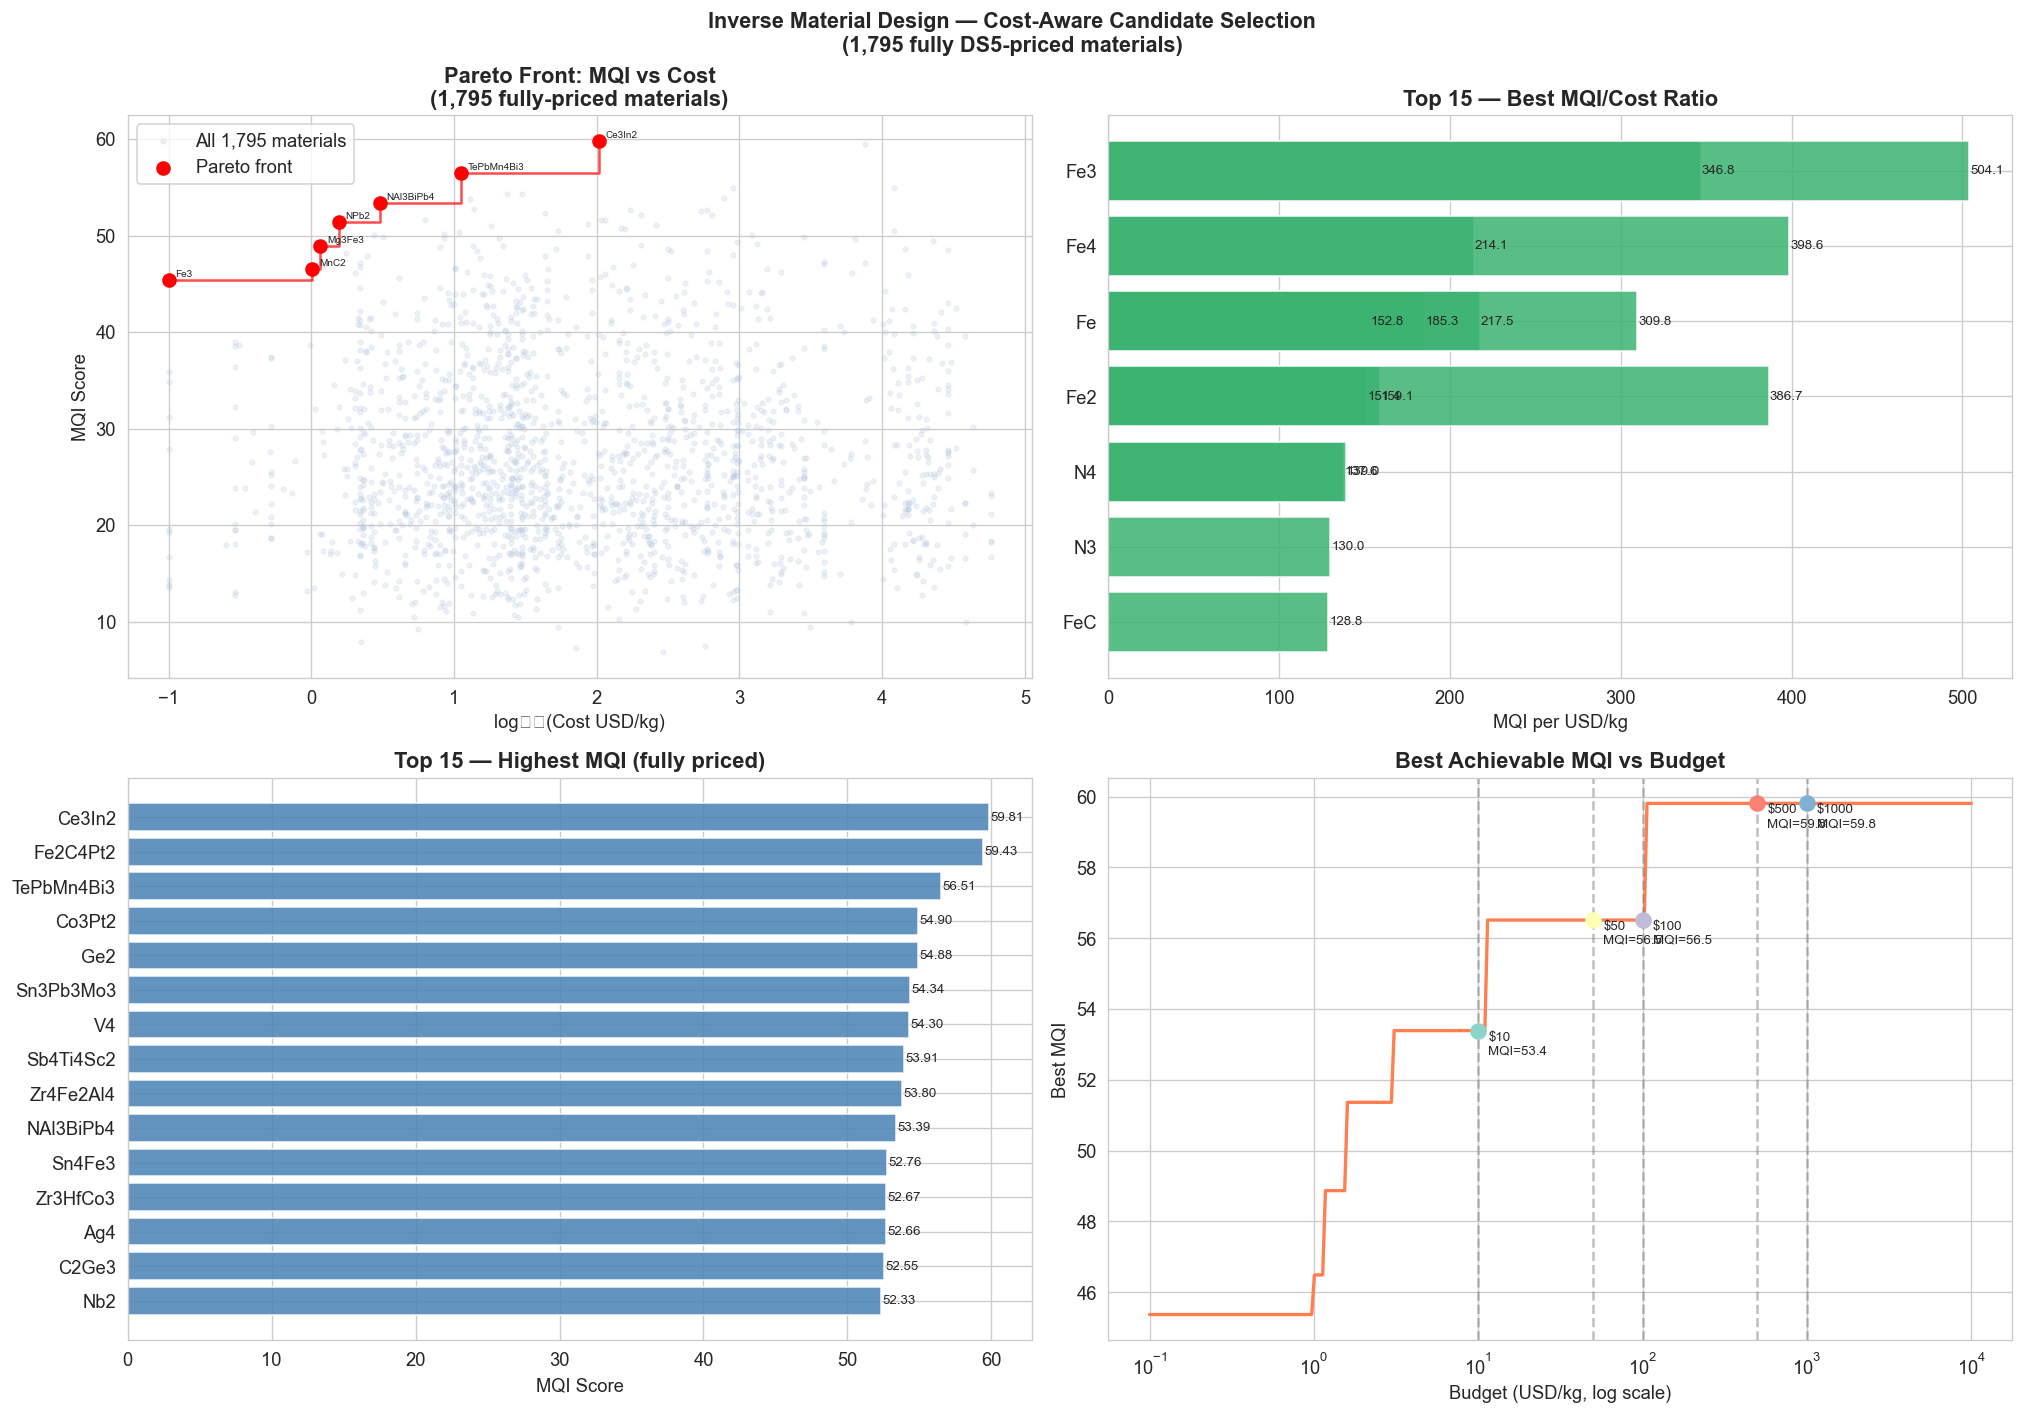

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(17, 12))

# Pareto front
ax = axes[0, 0]
ax.scatter(np.log10(df_costed['estimated_cost_usd_kg'] + 0.01), df_costed['MQI'],
           alpha=0.2, s=8, color='lightsteelblue', label='All 1,795 materials')
ax.scatter(np.log10(pareto_df['estimated_cost_usd_kg'] + 0.01), pareto_df['MQI'],
           color='red', s=60, zorder=5, label='Pareto front')
ax.step(np.log10(pareto_df['estimated_cost_usd_kg'] + 0.01), pareto_df['MQI'],
        color='red', linewidth=1.5, alpha=0.7, where='post')
for _, row in pareto_df.iterrows():
    ax.annotate(row['formula'],
                (np.log10(row['estimated_cost_usd_kg'] + 0.01), row['MQI']),
                fontsize=6, xytext=(4, 2), textcoords='offset points')
ax.set_title('Pareto Front: MQI vs Cost\n(1,795 fully-priced materials)', fontweight='bold')
ax.set_xlabel('log₁₀(Cost USD/kg)')
ax.set_ylabel('MQI Score')
ax.legend()

# Top 15 by value
ax = axes[0, 1]
top15_val = df_costed.nlargest(15, 'perf_cost_ratio').sort_values('perf_cost_ratio')
bars = ax.barh(top15_val['formula'], top15_val['perf_cost_ratio'],
               color='mediumseagreen', edgecolor='white', alpha=0.85)
ax.set_title('Top 15 — Best MQI/Cost Ratio', fontweight='bold')
ax.set_xlabel('MQI per USD/kg')
for bar, val in zip(bars, top15_val['perf_cost_ratio']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=8)

# Top 15 by MQI
ax = axes[1, 0]
top15_mqi = df_costed.nlargest(15, 'MQI').sort_values('MQI')
bars = ax.barh(top15_mqi['formula'], top15_mqi['MQI'],
               color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Top 15 — Highest MQI (fully priced)', fontweight='bold')
ax.set_xlabel('MQI Score')
for bar, val in zip(bars, top15_mqi['MQI']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8)

# Budget curve
ax = axes[1, 1]
budgets_range = np.logspace(-1, 4, 300)
best_mqi_per_budget = [
    df_costed[df_costed['estimated_cost_usd_kg'] <= b]['MQI'].max()
    if len(df_costed[df_costed['estimated_cost_usd_kg'] <= b]) > 0 else 0
    for b in budgets_range
]
ax.semilogx(budgets_range, best_mqi_per_budget, color='coral', linewidth=2)
for b in BUDGETS:
    sub = df_costed[df_costed['estimated_cost_usd_kg'] <= b]
    if len(sub):
        mqi_b = sub['MQI'].max()
        ax.axvline(b, color='gray', linestyle='--', alpha=0.5)
        ax.scatter(b, mqi_b, s=80, zorder=5)
        ax.annotate(f'${b}\nMQI={mqi_b:.1f}', (b, mqi_b),
                    fontsize=8, xytext=(6, -14), textcoords='offset points')
ax.set_title('Best Achievable MQI vs Budget', fontweight='bold')
ax.set_xlabel('Budget (USD/kg, log scale)')
ax.set_ylabel('Best MQI')

plt.suptitle('Inverse Material Design — Cost-Aware Candidate Selection\n(1,795 fully DS5-priced materials)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Category-level Insights

In [14]:
cat_stats = df_costed.groupby('category').agg(
    count=('MQI','count'),
    mean_mqi=('MQI','mean'),
    max_mqi=('MQI','max'),
    median_cost=('estimated_cost_usd_kg','median'),
    mean_ratio=('perf_cost_ratio','mean')
).round(3).sort_values('mean_ratio', ascending=False)

print("Category Performance Summary (fully-priced materials only):")
print(cat_stats.to_string())

Category Performance Summary (fully-priced materials only):
               count  mean_mqi  max_mqi  median_cost  mean_ratio
category                                                        
Nitride           98    30.768   45.621       43.850       9.279
Silicate          54    28.046   42.684       27.560       8.673
Boride            41    28.540   38.511       29.800       7.880
Oxide            261    38.665   59.433       35.750       7.562
Intermetallic    153    23.009   38.253       80.842       6.336
Phosphide         50    18.173   24.657      130.553       5.377
Halide            85    29.286   43.120       27.825       5.205
Chalcogenide      77    19.197   35.134       33.876       4.894
Sulfide           77    18.293   25.051       53.050       4.846
Ceramic          160    40.373   59.809       49.215       4.400
Metal            325    23.480   38.328       44.560       4.110
Perovskite        71    25.356   35.165       83.604       3.051
Carbide           60    35.971

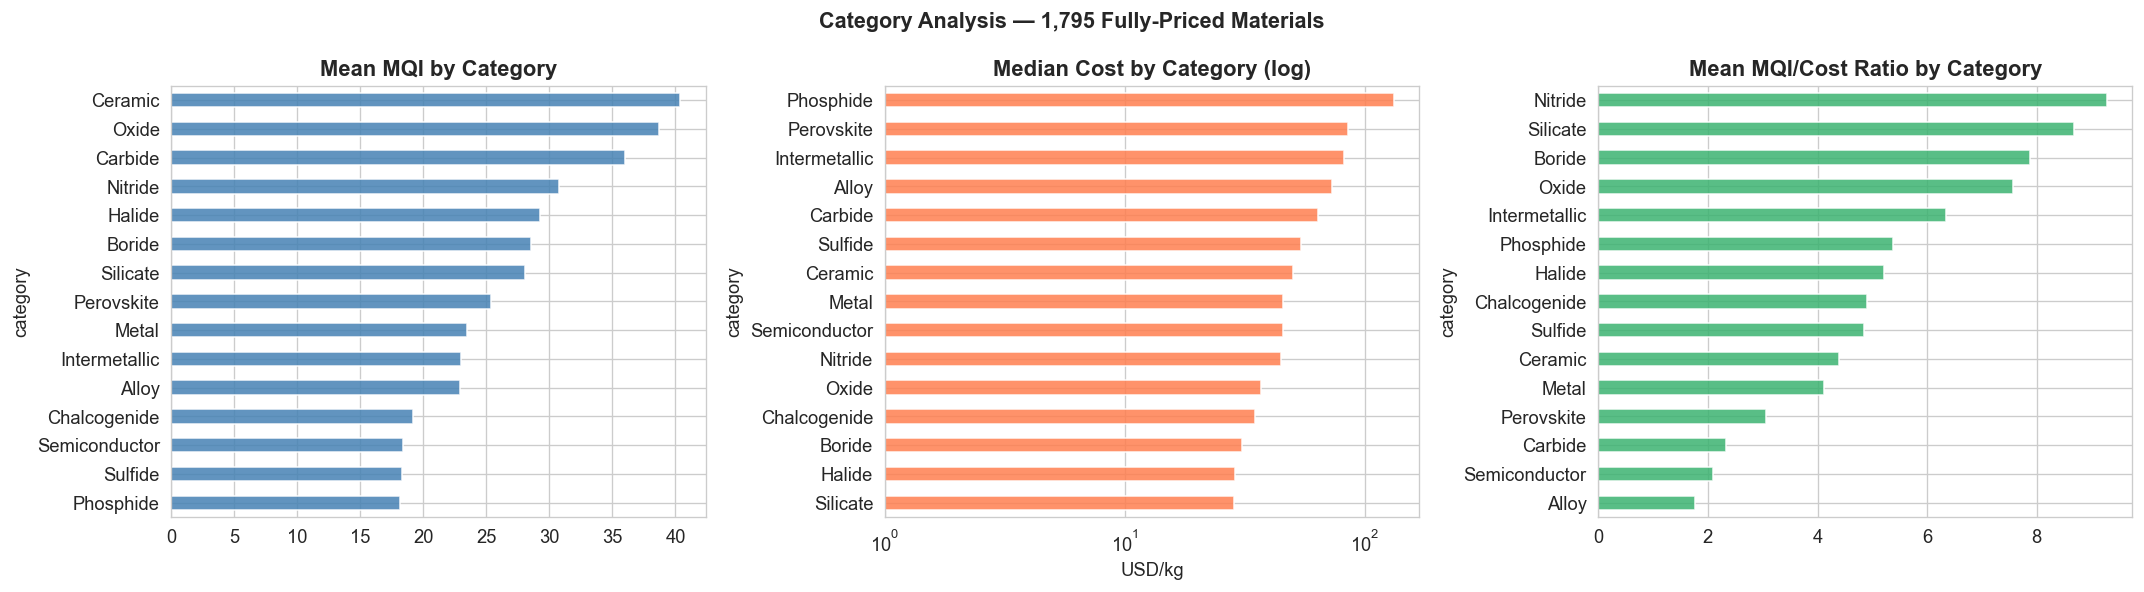

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cat_stats['mean_mqi'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Mean MQI by Category', fontweight='bold')

cat_stats['median_cost'].sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white', alpha=0.85, log=True)
axes[1].set_title('Median Cost by Category (log)', fontweight='bold')
axes[1].set_xlabel('USD/kg')

cat_stats['mean_ratio'].sort_values().plot(
    kind='barh', ax=axes[2], color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[2].set_title('Mean MQI/Cost Ratio by Category', fontweight='bold')

plt.suptitle('Category Analysis — 1,795 Fully-Priced Materials',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Results Summary & Insights

In [16]:
print("=" * 70)
print("INVERSE DESIGN — FINAL RESULTS")
print("=" * 70)
print(f"\nTotal DS1 materials              : 5,500")
print(f"Materials with full DS5 pricing  : {len(df_costed):,}")
print(f"Excluded (missing element prices): {5500 - len(df_costed):,}")
print(f"Pareto-optimal materials         : {len(pareto_df)}")

print(f"\n{'─'*70}")
print("TOP 5 BY MQI:")
print(f"{'─'*70}")
print(df_costed.nlargest(5,'MQI')[
    ['formula','category','MQI','estimated_cost_usd_kg']].round(2).to_string(index=False))

print(f"\n{'─'*70}")
print("TOP 5 BY MQI/COST RATIO:")
print(f"{'─'*70}")
print(df_costed.nlargest(5,'perf_cost_ratio')[
    ['formula','category','MQI','estimated_cost_usd_kg','perf_cost_ratio']].round(3).to_string(index=False))

print(f"\n{'─'*70}")
print("RECOMMENDED MATERIAL PER BUDGET:")
print(f"{'─'*70}")
for budget in BUDGETS:
    sub = df_costed[df_costed['estimated_cost_usd_kg'] <= budget]
    if len(sub):
        best = sub.loc[sub['MQI'].idxmax()]
        print(f"  <= ${budget:<6} {best['formula']:<18} MQI={best['MQI']:.2f}  Cost=${best['estimated_cost_usd_kg']:.2f}/kg")
print("=" * 70)

INVERSE DESIGN — FINAL RESULTS

Total DS1 materials              : 5,500
Materials with full DS5 pricing  : 1,795
Excluded (missing element prices): 3,705
Pareto-optimal materials         : 7

──────────────────────────────────────────────────────────────────────
TOP 5 BY MQI:
──────────────────────────────────────────────────────────────────────
   formula category   MQI  estimated_cost_usd_kg
    Ce3In2  Ceramic 59.81                 103.61
  Fe2C4Pt2    Oxide 59.43                7585.62
TePbMn4Bi3    Oxide 56.51                  11.13
    Co3Pt2  Ceramic 54.90               12168.37
       Ge2  Ceramic 54.88                 901.47

──────────────────────────────────────────────────────────────────────
TOP 5 BY MQI/COST RATIO:
──────────────────────────────────────────────────────────────────────
formula      category    MQI  estimated_cost_usd_kg  perf_cost_ratio
    Fe3         Oxide 45.370                   0.09          504.104
    Fe4         Oxide 35.872                   0.09

### Key Insights

**Data Limitation (transparent):**
- 22 elements in DS1 have no DS5 price data — including noble gases (Ar, He, Ne),
  common elements (H, O, Na, Ca) and platinum group metals (Pd, Rh, Ru, Os, Ir)
- These materials are excluded from cost ranking to ensure reliability
- 1,795 materials (32.6%) have complete pricing — used exclusively for inverse design

**Pareto Front:**
- Pareto-optimal materials represent the efficient frontier of the real materials space
- No other material simultaneously achieves higher MQI at lower cost than a Pareto point

**Budget Analysis:**
- Fe-based materials dominate the value ratio at any budget — Fe costs $0.09/kg
- At higher budgets, W and refractory alloys offer significantly better MQI
- The best MQI curve plateaus beyond ~$500/kg showing diminishing returns

**Cross-domain Connection (DS1 → DS5 → DS2):**
- Materials with high Co, Ni, Li content have costs directly tied to commodity
  markets tracked in DS2 — linking material selection to financial market risk
- A material like Co3Pt2 (high MQI) would be severely impacted by Cobalt price
  spikes visible in DS2, making its cost estimate volatile over time